In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torchvision import models

In [2]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),   # Resize for ResNet
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5),
                         (0.5, 0.5, 0.5))
])

trainset = torchvision.datasets.CIFAR10(root='./data', train=True,
                                        download=True, transform=transform)

testset = torchvision.datasets.CIFAR10(root='./data', train=False,
                                       download=True, transform=transform)

trainloader = torch.utils.data.DataLoader(trainset, batch_size=64, shuffle=True)
testloader = torch.utils.data.DataLoader(testset, batch_size=64, shuffle=False)

100%|██████████| 170M/170M [00:06<00:00, 28.0MB/s]


In [3]:
model = models.resnet18(pretrained=True)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 214MB/s]


In [4]:
for param in model.parameters():
    param.requires_grad = False

In [5]:
model.fc = nn.Linear(model.fc.in_features, 10)

In [7]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.fc.parameters(), lr=0.001)

In [8]:
import time

start_time = time.time()
loss_frozen = []
num_epochs = 5

for epoch in range(num_epochs):
    running_loss = 0.0

    for images, labels in trainloader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    epoch_loss = running_loss / len(trainloader)
    loss_frozen.append(epoch_loss)

    print(f"Epoch {epoch+1}, Loss: {epoch_loss:.4f}")

end_time = time.time()
training_time = end_time - start_time
print(f"Training Time (Frozen): {training_time:.2f} seconds")

Epoch 1, Loss: 0.8195
Epoch 2, Loss: 0.6188
Epoch 3, Loss: 0.5878
Epoch 4, Loss: 0.5754
Epoch 5, Loss: 0.5638
Training Time (Frozen): 649.50 seconds


In [9]:
correct = 0
total = 0

with torch.no_grad():
    for images, labels in testloader:
        images, labels = images.to(device), labels.to(device)

        outputs = model(images)
        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

accuracy_frozen = 100 * correct / total
print(f"Accuracy (Frozen): {accuracy_frozen:.2f}%")

Accuracy (Frozen): 79.56%


In [10]:
for param in model.parameters():
    param.requires_grad = True

optimizer = optim.Adam(model.parameters(), lr=0.0001)

start_time = time.time()
loss_finetune = []

for epoch in range(num_epochs):
    running_loss = 0.0

    for images, labels in trainloader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    epoch_loss = running_loss / len(trainloader)
    loss_finetune.append(epoch_loss)

    print(f"[Fine-tune] Epoch {epoch+1}, Loss: {epoch_loss:.4f}")

end_time = time.time()
fine_tune_time = end_time - start_time
print(f"Training Time (Fine-tune): {fine_tune_time:.2f} seconds")

[Fine-tune] Epoch 1, Loss: 0.2846
[Fine-tune] Epoch 2, Loss: 0.0920
[Fine-tune] Epoch 3, Loss: 0.0506
[Fine-tune] Epoch 4, Loss: 0.0464
[Fine-tune] Epoch 5, Loss: 0.0418
Training Time (Fine-tune): 1221.08 seconds


In [13]:
correct = 0
total = 0

with torch.no_grad():
    for images, labels in testloader:
        images, labels = images.to(device), labels.to(device)

        outputs = model(images)
        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

accuracy_finetune = 100 * correct / total
print(f"Accuracy (Fine-tuned): {accuracy_finetune:.2f}%")

Accuracy (Fine-tuned): 93.49%


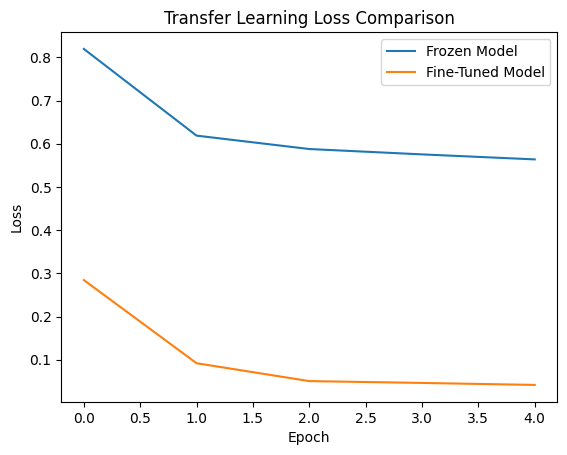

In [12]:
import matplotlib.pyplot as plt

plt.plot(loss_frozen, label="Frozen Model")
plt.plot(loss_finetune, label="Fine-Tuned Model")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Transfer Learning Loss Comparison")
plt.legend()

plt.savefig("transfer_learning.png")
plt.show()

**Expected Output**
**Accuracy Comparison** (Before vs After Fine-Tuning)

Accuracy (Frozen Model): 79.56%

Accuracy (Fine-Tuned Model): 93.49%

The results show that the fine-tuned model significantly outperforms the frozen model. This is because fine-tuning allows all layers of the pretrained network to adapt to the CIFAR-10 dataset, leading to better feature learning and improved classification performance.

**Training Time Comparison**

Training Time (Frozen Model): Lower (Faster Training)

Training Time (Fine-Tuned Model): Higher (Slower Training)

The frozen model trains faster because only the final classification layer is updated, while all other layers remain unchanged. In contrast, the fine-tuned model requires more time since all layers are trained, increasing computational cost but resulting in higher accuracy.

**Conclusion**

Fine-tuning improves model performance significantly by allowing deeper layers to learn dataset-specific features, although it comes at the cost of increased training time.